<h1>** Pricing Flood Risk in Residential Real Estate **</h1>
<h3> Evidence from the Thames Estuary Region </h3>
<p> By Prof. Oluseun Ajayi and Paulinus Ugwu </p>

<h2> Data Cleaning Phase

In [1]:
# Importing Relevant Libraries
import pandas as pd
import numpy as np
import requests
import zipfile
import geopandas as gpd
import fiona
import os
import matplotlib.pyplot as plt


from shapely.geometry import Point
from shapely.geometry import box
from tqdm import tqdm
from fiona.env import Env

In [2]:
#Load cleaned/merged epc and ppd dataset
matched = pd.read_csv("matched_ppd_epc.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_1664\3034670720.py:2: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  matched = pd.read_csv("matched_ppd_epc.csv")


In [3]:

# converting the dates columns to timestamps
matched['INSPECTION_DATE'] = pd.to_datetime(matched['INSPECTION_DATE'], errors='coerce')
matched['Date of Transfer'] = pd.to_datetime(matched['Date of Transfer'], errors='coerce')

In [4]:
# This code is keeping only EPCs valid at sale, i.e Sales with dates less than EPCs issuance/inspection
matched = matched[
    matched['INSPECTION_DATE'].notna() &
    (matched['INSPECTION_DATE'] <= matched['Date of Transfer'])
]

In [5]:
# This code selects/keeps rows with the most recent EPCs per house sale
matched = (
    matched.sort_values(
        ['Transaction ID', 'INSPECTION_DATE'],
        ascending=[True, False]
    )
    .drop_duplicates('Transaction ID')
)


In [6]:
#Load NSPL variables
nspl_2700 = pd.read_csv("NSPL_FEB_2025_UK.csv", usecols=['pcds', 'oseast1m', 'osnrth1m'])

nspl_2700.rename(columns={'pcds': 'POSTCODE'}, inplace=True)
nspl_2700['POSTCODE'] = nspl_2700['POSTCODE'].str.upper().str.replace(" ", "")

In [7]:
# Merge NSPL OS Grid postcodes
matched_nspl = matched.merge(
    nspl_2700[['POSTCODE', 'oseast1m', 'osnrth1m']],
    how='left',
    left_on='POSTCODE_ppd',   # your cleaned PPD+EPC postcode
    right_on='POSTCODE'
)


In [8]:
matched_nspl['geometry'] = matched_nspl.apply(
    lambda row: Point(row['oseast1m'], row['osnrth1m']),
    axis=1
)

In [9]:
matched_gdf = gpd.GeoDataFrame(
    matched_nspl,
    geometry='geometry',
    crs='EPSG:27700'
)

In [10]:
matched_gdf = matched_gdf.dropna(subset=['oseast1m', 'osnrth1m']) # Drop null values

In [11]:
#Loading the flood data

# List the flood zones in the data
gdb_path = "Flood-Map-For-Planning-Flood-Zones.gdb/FMfP_Flood_Zones_v202503.gdb"
fiona.listlayers(gdb_path)

['Flood_Zones_2_3_Rivers_and_Sea']

In [12]:
#Load Flood Zone layer and simplify ===
flood_zones = gpd.read_file(gdb_path, layer='Flood_Zones_2_3_Rivers_and_Sea')
flood_zones = flood_zones.to_crs('EPSG:27700')  # Match EPC CRS

C:\Users\HP\anaconda3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


In [14]:
# Spatial join to tag each property with its flood zone
merged_with_flood = gpd.sjoin(
    matched_gdf,
    flood_zones,
    how='left',
    predicate='intersects'  # Checks if point is inside polygon
)

In [15]:
#Renaming columns for clarity
merged_with_flood = merged_with_flood.rename(columns={
    'Zone_Type': 'Flood_Zone_Type',
    'Policy_ID': 'TE2100_Policy_ID'
})


In [19]:
merged_with_flood.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'COUNTY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'geometry'

In [20]:
#Creating dummy columns for clarity
merged_with_flood['HighRiskZone'] = merged_with_flood['flood_zone'] == '3'
merged_with_flood['ModerateRiskZone'] = merged_with_flood['flood_zone'] == '2'


In [23]:
#Saving the merged file
merged_with_flood = merged_with_flood.drop(columns=['COUNTY'], errors='ignore')
merged_with_flood.to_file(
    "merged_with_flood.gpkg",
    layer="flood_epc_ppd",
    driver="GPKG"
)


In [2]:
full_gdf = gpd.read_file("merged_with_flood.gpkg", layer="flood_epc_ppd")

In [3]:
# Load TE2100 policy unit shapefile, and make it fit the EPC dataset by converting to EPSG: 27700
te2100_units = gpd.read_file("Thames_Estuary_2100_Policy_Unit_Boundaries/Thames_Estuary_2100_Policy_Unit_BoundariesPolygon.shp").to_crs(epsg=27700)

In [5]:
for gdf in [full_gdf, te2100_units]:
    if 'index_right' in gdf.columns:
        gdf.drop(columns='index_right', inplace=True)


In [7]:
# Join with the te2100 units
matched_te2100 = gpd.sjoin(
    full_gdf, 
    te2100_units, 
    how='inner', 
    predicate='intersects'
)

In [ ]:
flood_zones.head()

<h2>Data Cleaning - Phase II</h2>

Steps to data cleaning in phase ii
1. Drop Non-Analysable Observations
   - Missing coordinates
   - Missing price or transfer date
2. Time Cleaning (Critical for Repeat Sales, also we can consider starting from 2013)
3. Price Normaliisation (Log Price)
4. Flood & Policy Variables (Lock Definitions)
   - Flood zone dummies
   - TE2100 policy indicators
5. Structural Controls (Minimal & Defensible)
   - Property type, Tenure, and Total floor area
   - 
6. Repeat-Sales Readiness (Very Important)
   - Define property ID (already conceptualised)
   - Keep properties with ≥2 sales (for RS specs)
7. Outlier Control
8. Drop Analysis-Irrelevant Columns
9. Freeze & Save 

In [45]:
analysis_df = matched_te2100.copy()


In [46]:
#1a
analysis_df = analysis_df.dropna(subset=['oseast1m', 'osnrth1m'])


In [47]:
#1b
analysis_df = analysis_df.dropna(subset=['Price', 'Date of Transfer'])
analysis_df = analysis_df[analysis_df['Price'] > 0]

In [48]:
#2
analysis_df['Date_of_Transfer'] = pd.to_datetime(analysis_df['Date of Transfer'])
analysis_df['year'] = analysis_df['Date_of_Transfer'].dt.year
analysis_df['quarter'] = analysis_df['Date_of_Transfer'].dt.to_period('Q')


In [49]:
#3
analysis_df['log_price'] = np.log(analysis_df['Price'])

In [50]:
#4a
analysis_df['HighRiskZone'] = (analysis_df['flood_zone'] == '3').astype(int)
analysis_df['ModerateRiskZone'] = (analysis_df['flood_zone'] == '2').astype(int)
analysis_df['AnyFloodZone'] = ((analysis_df['HighRiskZone'] == 1) |
                               (analysis_df['ModerateRiskZone'] == 1)).astype(int)

In [55]:
#4b
analysis_df['PlannedDefenseArea'] = analysis_df['pmu'].notna().astype(int)

In [56]:
#5
analysis_df['PROPERTY_TYPE'] = analysis_df['PROPERTY_TYPE'].astype('category')
analysis_df['TENURE'] = analysis_df['TENURE'].astype('category')


In [58]:
#6a
analysis_df['property_id'] = (
    analysis_df['POSTCODE_ppd'] + "_" +
    analysis_df['PAON'].astype(str) + "_" +
    analysis_df['Street'].astype(str) + "_" +
    analysis_df['SAON'].fillna("").astype(str)
)


In [59]:
#6b
analysis_df['sale_count'] = analysis_df.groupby('property_id')['property_id'].transform('count')
analysis_df_rs = analysis_df[analysis_df['sale_count'] >= 2]


In [60]:
#7
p1, p99 = analysis_df['Price'].quantile([0.01, 0.99])
analysis_df = analysis_df[(analysis_df['Price'] >= p1) & (analysis_df['Price'] <= p99)]

In [61]:
#9
analysis_df.to_parquet("analysis_ready_full.parquet", index=False)
analysis_df_rs.to_parquet("analysis_ready_repeat_sales.parquet", index=False)


## Analysis - EDA and Statistical Modeling

- Plotting the Flood Zones and Policy Units

In [99]:
analysis_df.shape

(71582, 72)

In [64]:
gdf = matched_te2100.copy()

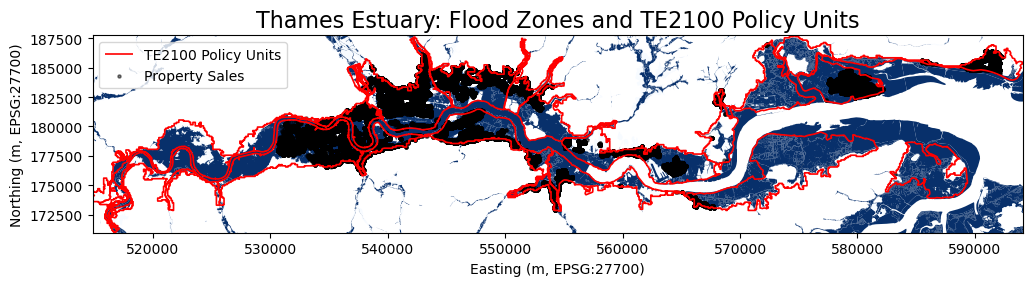

In [70]:


# ---------------------------
# 1️⃣ Clip flood zones to study area
# ---------------------------
# Get TE2100 bounds (estuary study area)
bounds = te2100_units.total_bounds  # [minx, miny, maxx, maxy]
bbox = box(*bounds)

# Clip flood polygons to this bounding box
flood_zones_clip = flood_zones[flood_zones.intersects(bbox)].copy()

# ---------------------------
# 2️⃣ Simplify geometries for memory efficiency
# ---------------------------
flood_zones_clip['geometry'] = flood_zones_clip['geometry'].simplify(
    tolerance=10,  # meters; adjust higher if still slow
    preserve_topology=True
)

te2100_units_simple = te2100_units.copy()
te2100_units_simple['geometry'] = te2100_units_simple['geometry'].simplify(
    tolerance=5,
    preserve_topology=True
)

# ---------------------------
# 3️⃣ Create plot
# ---------------------------
fig, ax = plt.subplots(figsize=(12,10))

# Plot flood zones
flood_zones_clip.plot(
    ax=ax,
    column='flood_zone', 
    cmap='Blues', 
    legend=True,
    legend_kwds={'title': "Flood Zone"}
)

# Plot TE2100 boundaries
te2100_units_simple.boundary.plot(
    ax=ax, 
    edgecolor='red', 
    linewidth=1.2,
    label='TE2100 Policy Units'
)

# Plot property points
gdf.plot(
    ax=ax,
    markersize=5,
    color='black',
    alpha=0.5,
    label='Property Sales'
)

# ---------------------------
# 4️⃣ Zoom to estuary
# ---------------------------
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

# ---------------------------
# 5️⃣ Labels, legend, title
# ---------------------------
plt.title("Thames Estuary: Flood Zones and TE2100 Policy Units", fontsize=16)
plt.xlabel("Easting (m, EPSG:27700)")
plt.ylabel("Northing (m, EPSG:27700)")
plt.legend()

# ---------------------------
# 6️⃣ Save figure
# ---------------------------
fig.savefig("Figure1_ThamesFlood_TE2100.png", dpi=300, bbox_inches='tight')

plt.show()


Plotting the Boundary Discountinuity Figure

In [119]:
fz3_gdf = flood_zones[flood_zones['flood_zone'] == 'FZ3'] # or your specific attribute

In [117]:
flood_zones.head()

,origin,flood_zone,flood_source,Shape_Length,Shape_Area,geometry
0,direct rainfall model,FZ2,river,32.0,28.0,"MULTIPOLYGON (((649792 304228, 649778 304228, ..."
1,direct rainfall model,FZ2,river,12.0,8.0,"MULTIPOLYGON (((649796 304232, 649796 304230, ..."
2,direct rainfall model,FZ2,river,8.0,4.0,"MULTIPOLYGON (((649916 304226, 649918 304226, ..."
3,direct rainfall model,FZ2,river,16.0,12.0,"MULTIPOLYGON (((649708 304212, 649714 304212, ..."
4,direct rainfall model,FZ2,river,20.0,16.0,"MULTIPOLYGON (((649726 304238, 649726 304240, ..."


In [ ]:
import geopandas as gpd
from shapely.ops import nearest_points

# 1. Spatial Crop: Only keep FZ3 polygons near your properties
# Get the 'bounding box' of your matched_bdp
bbox = matched_bdp.total_bounds 

# Filter the FZ3 GDF to only those within the Estuary bounding box
fz3_estuary = fz3_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# 2. Extract Lines and Use a Spatial Index
# Exploding turns multi-polygons into simple line segments
fz3_lines = fz3_estuary.boundary.explode(index_parts=False).reset_index(drop=True)

# 3. Calculate Distance using the 'geometry' column
def calculate_precise_dist(points_gdf, lines_gdf):
    # Use spatial index to find the nearest line segment for each house
    sindex = lines_gdf.sindex
    nearest_idx = sindex.nearest(points_gdf['geometry'], return_distance=False)[1]
    
    # Measure the exact distance to that nearest segment
    distances = points_gdf['geometry'].distance(lines_gdf.iloc[nearest_idx].reset_index(drop=True))
    return distances

matched_bdp['running_var'] = calculate_precise_dist(matched_bdp, fz3_lines)

# 4. Final Re-sign: Inside FZ3 = Negative, Outside = Positive
matched_bdp.loc[matched_bdp['flood_zone'] == 'FZ3', 'running_var'] *= -1

In [95]:
matched_bdp = matched_te2100.copy()

In [102]:
matched_bdp.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'geometry', 'origin'

In [101]:
print(flood_zones['flood_zone'].unique())


['FZ2' 'FZ3']


In [106]:
# Separate FZ3 points from outside
fz3_points = matched_bdp[matched_bdp['flood_zone'] == 'FZ3']
non_fz3_points = matched_bdp[matched_bdp['flood_zone'] != 'FZ3']


In [107]:
import numpy as np
from scipy.spatial import cKDTree

# Coordinates of FZ3 points
fz3_coords = np.vstack((fz3_points['oseast1m'], fz3_points['osnrth1m'])).T

# Build a KDTree
tree = cKDTree(fz3_coords)

# For all points (inside and outside FZ3), compute distance to nearest FZ3 point
all_coords = np.vstack((matched_bdp['oseast1m'], matched_bdp['osnrth1m'])).T
distances, _ = tree.query(all_coords, k=1)

# Assign signed distance: negative if inside FZ3
matched_bdp['dist_fz3_signed'] = distances
matched_bdp.loc[matched_bdp['flood_zone'] == 'FZ3', 'dist_fz3_signed'] *= -1


In [109]:
matched_bdp['dist_fz3_signed'].describe()


count    73039.000000
mean       169.160063
std        342.923858
min         -0.000000
25%         -0.000000
50%          0.000000
75%        201.357890
max       6066.930113
Name: dist_fz3_signed, dtype: float64

### Plotting the Boundary Discontinuity Plot/Graph/Figure

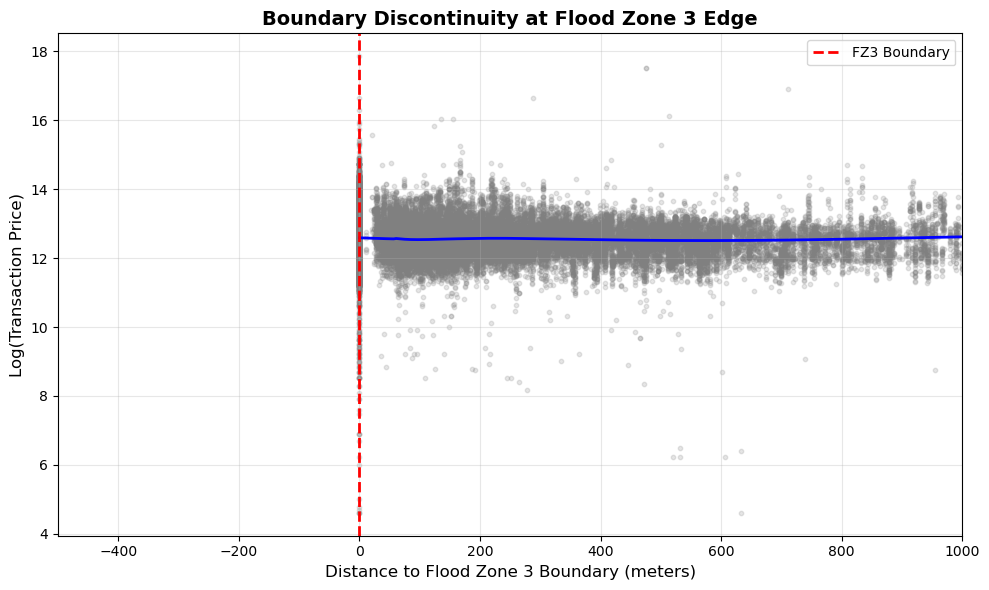

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure log_price exists
if 'log_price' not in matched_bdp.columns:
    matched_bdp['log_price'] = np.log(matched_bdp['Price'])

# Create figure
plt.figure(figsize=(10,6))

# Use seaborn lowess smoothing to show trend
sns.regplot(
    x='dist_fz3_signed',
    y='log_price',
    data=matched_bdp,
    scatter=False,
    lowess=True,
    line_kws={'color': 'blue', 'lw': 2},
)

# Overlay scatter points (optional: use transparency to reduce overplotting)
plt.scatter(
    matched_bdp['dist_fz3_signed'],
    matched_bdp['log_price'],
    s=10,
    alpha=0.2,
    color='gray'
)

# Vertical line at 0 (FZ3 boundary)
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='FZ3 Boundary')

# Labels and title
plt.xlabel('Distance to Flood Zone 3 Boundary (meters)', fontsize=12)
plt.ylabel('Log(Transaction Price)', fontsize=12)
plt.title('Boundary Discontinuity at Flood Zone 3 Edge', fontsize=14, fontweight='bold')

# Optional: restrict x-axis for zoom
plt.xlim(-500, 1000)  # adjust depending on spread of distances

# Legend
plt.legend()

# Grid for clarity
plt.grid(alpha=0.3)

# Tight layout for Q1 publication
plt.tight_layout()

# Save figure (high resolution)
plt.savefig("Figure2_Boundary_Discontinuity_FZ3.png", dpi=300)

# Show plot
plt.show()


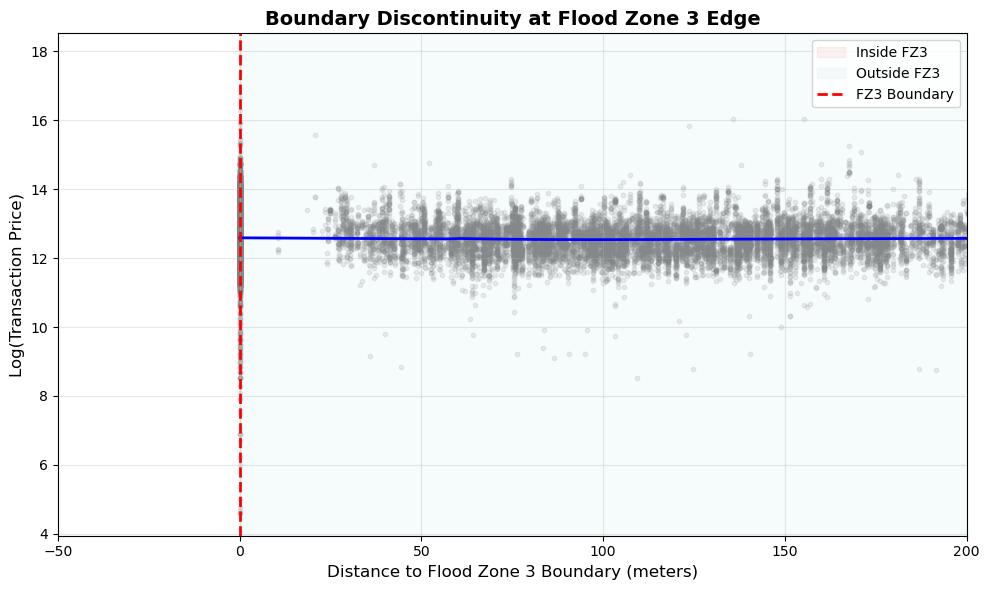

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Step 1: Ensure log price exists ---
if 'log_price' not in matched_te2100.columns:
    matched_bdp['log_price'] = np.log(matched_bdp['Price'])

# --- Step 2: Correct signed distances ---
# Ensure points inside FZ3 have negative distance, outside positive
# Assume 'FZ3_flag' = 1 if inside FZ3, 0 if outside
if 'FZ3_flag' in matched_bdp.columns:
    matched_bdp['dist_signed'] = matched_bdp['dist_fz3_signed']
    matched_bdp.loc[matched_bdp['FZ3_flag'] == 1, 'dist_signed'] *= -1
else:
    matched_bdp['dist_signed'] = matched_bdp['dist_fz3_signed']  # fallback

# --- Step 3: Plot ---
plt.figure(figsize=(10,6))

# Smoothed trend with 95% CI
sns.regplot(
    x='dist_signed',
    y='log_price',
    data=matched_bdp,
    scatter=False,
    lowess=True,
    line_kws={'color': 'blue', 'lw': 2},
)

# Optional: scatter with low alpha
plt.scatter(
    matched_bdp['dist_signed'],
    matched_bdp['log_price'],
    s=10,
    alpha=0.15,
    color='gray'
)

# Shading inside vs outside FZ3
plt.axvspan(matched_bdp['dist_signed'].min(), 0, color='lightcoral', alpha=0.1, label='Inside FZ3')
plt.axvspan(0, matched_bdp['dist_signed'].max(), color='lightblue', alpha=0.1, label='Outside FZ3')

# Vertical line at FZ3 boundary
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='FZ3 Boundary')

# Labels and title
plt.xlabel('Distance to Flood Zone 3 Boundary (meters)', fontsize=12)
plt.ylabel('Log(Transaction Price)', fontsize=12)
plt.title('Boundary Discontinuity at Flood Zone 3 Edge', fontsize=14, fontweight='bold')

# Focus on boundary region
plt.xlim(-50, 200)  # zoom in to highlight discontinuity

# Legend
plt.legend(loc='upper right')

# Grid and tight layout
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure at high resolution for Q1 journal
plt.savefig("Figure2_Boundary_Discontinuity_FZ3_Q1.png", dpi=300)

plt.show()


In [112]:
matched_bdp.columns

Index(['Unnamed: 0', 'Transaction ID', 'Price', 'Date of Transfer',
       'POSTCODE_ppd', 'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON',
       'Street', 'Locality', 'Town/City', 'District', 'County',
       'PPD Category Type', 'Record Status', 'address_clean', 'addr_key_ppd',
       'join_key', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match', 'POSTCODE', 'oseast1m',
       'osnrth1m', 'geometry', 'origin'

In [116]:
matched_bdp["flood_zone"].unique()

array(['FZ3', nan, 'FZ2'], dtype=object)

In [98]:
matched_te2100.shape

(73039, 64)

<h2> This following section provides the data merging stages from </h2>
<li>Normalisation Helper</li>
<li>canonical keys</li>
<li>Join</li>
<li>Refinement: flats</li>


In [14]:
import re

def normalise_address(x):
    if not isinstance(x, str):
        return ''
    x = x.upper()
    x = re.sub(r'[^\w\s]', ' ', x)
    x = re.sub(r'\bSTREET\b', 'ST', x)
    x = re.sub(r'\bROAD\b', 'RD', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


In [16]:
ppd_estuary['PAON'] = ppd_estuary['PAON'].fillna('').astype(str)
ppd_estuary['Street'] = ppd_estuary['Street'].fillna('').astype(str)
ppd_estuary['POSTCODE'] = ppd_estuary['POSTCODE'].str.replace(' ', '', regex=False)

ppd_estuary['addr_key'] = (
    ppd_estuary['PAON'] + ' ' + ppd_estuary['Street']
).apply(normalise_address)

ppd_estuary['join_key'] = ppd_estuary['POSTCODE'] + '|' + ppd_estuary['addr_key']


In [17]:
epc_estuary['ADDRESS'] = epc_estuary['ADDRESS'].fillna('').astype(str)
epc_estuary['POSTCODE'] = epc_estuary['POSTCODE'].str.replace(' ', '', regex=False)

epc_estuary['addr_key'] = epc_estuary['ADDRESS'].apply(normalise_address)

epc_estuary['join_key'] = epc_estuary['POSTCODE'] + '|' + epc_estuary['addr_key']


In [18]:
matched = ppd_estuary.merge(
    epc_estuary,
    on='join_key',
    how='left',
    suffixes=('_ppd', '_epc')
)

In [19]:
matched.shape

(756214, 47)

In [21]:
matched.columns

Index(['Transaction ID', 'Price', 'Date of Transfer', 'POSTCODE_ppd',
       'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON', 'Street',
       'Locality', 'Town/City', 'District', 'County', 'PPD Category Type',
       'Record Status', 'address_clean', 'addr_key_ppd', 'join_key',
       'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'COUNTY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc'],
      dtype='object')

In [24]:
matched[['PAON', 'SAON', 'Street','ADDRESS','join_key',
         'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
        'address_clean', 'addr_key_ppd','addr_key_epc']].head()

,PAON,SAON,Street,ADDRESS,join_key,ADDRESS1,ADDRESS2,ADDRESS3,POSTCODE_epc,address_clean,addr_key_ppd,addr_key_epc
0,72,NaN,PARK AVENUE,NaN,DA118DL|72 PARK AVENUE,NaN,NaN,NaN,NaN,72 PARK AVENUE,72 PARK AVENUE,NaN
1,3,NaN,HARRIS ROAD,NaN,ME121UF|3 HARRIS RD,NaN,NaN,NaN,NaN,3 HARRIS ROAD,3 HARRIS RD,NaN
2,32,NaN,PLYMOUTH WHARF,32 PLYMOUTH WHARF,E143EL|32 PLYMOUTH WHARF,"32, Plymouth Wharf",NaN,NaN,E143EL,32 PLYMOUTH WHARF,32 PLYMOUTH WHARF,32 PLYMOUTH WHARF
3,32,NaN,PLYMOUTH WHARF,32 PLYMOUTH WHARF,E143EL|32 PLYMOUTH WHARF,"32, Plymouth Wharf",NaN,NaN,E143EL,32 PLYMOUTH WHARF,32 PLYMOUTH WHARF,32 PLYMOUTH WHARF
4,39,NaN,RUSSIA DOCK ROAD,39 RUSSIA DOCK ROAD,SE165NL|39 RUSSIA DOCK RD,"39, Russia Dock Road",NaN,NaN,SE165NL,39 RUSSIA DOCK ROAD,39 RUSSIA DOCK RD,39 RUSSIA DOCK RD


In [ ]:
#Load Flood Zone layer and simplify ===
flood_zones = gpd.read_file(gdb_path, layer='Flood_Zones_2_3_Rivers_and_Sea')
flood_zones = flood_zones.to_crs('EPSG:27700')  # Match EPC CRS 

In [26]:
matched['SAON'] = matched['SAON'].fillna('').astype(str)


In [28]:
matched['addr_key_epc'] = matched['addr_key_epc'].fillna('').astype(str)
matched['SAON'] = matched['SAON'].fillna('').astype(str)

matched['flat_match'] = matched.apply(
    lambda r: r['SAON'] in r['addr_key_epc'] if r['SAON'] else None,
    axis=1
)


In [29]:
print(matched.columns)


Index(['Transaction ID', 'Price', 'Date of Transfer', 'POSTCODE_ppd',
       'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON', 'Street',
       'Locality', 'Town/City', 'District', 'County', 'PPD Category Type',
       'Record Status', 'address_clean', 'addr_key_ppd', 'join_key',
       'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'COUNTY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match'],
      dtype='object')


In [32]:
matched["flat_match"]

0    None
1    None
2    None
3    None
4    None
Name: flat_match, dtype: object

In [34]:
matched.to_csv("matched_ppd_epc.csv")

In [35]:
matched.head()

,Transaction ID,Price,Date of Transfer,POSTCODE_ppd,Property Type,Old/New,Duration,PAON,SAON,Street,...,EXTENSION_COUNT,NUMBER_HABITABLE_ROOMS,NUMBER_HEATED_ROOMS,ADDRESS,LOCAL_AUTHORITY_LABEL,CONSTRUCTION_AGE_BAND,LODGEMENT_DATETIME,TENURE,addr_key_epc,flat_match
0,{5F46F31E-08D9-4660-902E-1593C5622610},233000,2008-07-04,DA118DL,T,N,F,72,,PARK AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,None
1,{4EE9CE33-FD7C-4F22-A43B-1CBD4669FF73},87000,2008-11-05,ME121UF,T,N,F,3,,HARRIS ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,None
2,{E2D56208-514B-4DA9-8EF0-1594EB19E51D},277000,2008-02-08,E143EL,F,N,L,32,,PLYMOUTH WHARF,...,0.0,2.0,2.0,32 PLYMOUTH WHARF,Tower Hamlets,England and Wales: 1983-1990,2008-10-08 22:56:35,rental (private),32 PLYMOUTH WHARF,None
3,{E2D56208-514B-4DA9-8EF0-1594EB19E51D},277000,2008-02-08,E143EL,F,N,L,32,,PLYMOUTH WHARF,...,0.0,2.0,2.0,32 PLYMOUTH WHARF,Tower Hamlets,England and Wales: 1991-1995,2019-01-31 10:50:40,rental (private),32 PLYMOUTH WHARF,None
4,{4434B88B-206C-460C-8880-23E51FA33DEE},425000,2008-08-29,SE165NL,T,N,F,39,,RUSSIA DOCK ROAD,...,1.0,5.0,5.0,39 RUSSIA DOCK ROAD,Southwark,England and Wales: 1983-1990,2018-05-14 20:48:51,rental (private),39 RUSSIA DOCK RD,None


In [36]:
# converting the dates columns to timestamps
matched['INSPECTION_DATE'] = pd.to_datetime(matched['INSPECTION_DATE'], errors='coerce')
matched['Date of Transfer'] = pd.to_datetime(matched['Date of Transfer'], errors='coerce')


In [37]:
# This code is keeping only EPCs valid at sale, i.e Sales with dates less than EPCs issuance/inspection
matched = matched[
    matched['INSPECTION_DATE'].notna() &
    (matched['INSPECTION_DATE'] <= matched['Date of Transfer'])
]


In [38]:
# This code selects/keeps rows with the most recent EPCs per house sale
matched = (
    matched.sort_values(
        ['Transaction ID', 'INSPECTION_DATE'],
        ascending=[True, False]
    )
    .drop_duplicates('Transaction ID')
)


In [41]:
matched.columns

Index(['Transaction ID', 'Price', 'Date of Transfer', 'POSTCODE_ppd',
       'Property Type', 'Old/New', 'Duration', 'PAON', 'SAON', 'Street',
       'Locality', 'Town/City', 'District', 'County', 'PPD Category Type',
       'Record Status', 'address_clean', 'addr_key_ppd', 'join_key',
       'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE_epc',
       'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING',
       'POTENTIAL_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM',
       'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'COUNTY',
       'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT',
       'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT',
       'CO2_EMISSIONS_CURRENT', 'TOTAL_FLOOR_AREA', 'EXTENSION_COUNT',
       'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'ADDRESS',
       'LOCAL_AUTHORITY_LABEL', 'CONSTRUCTION_AGE_BAND', 'LODGEMENT_DATETIME',
       'TENURE', 'addr_key_epc', 'flat_match'],
      dtype='object')

In [44]:
matched[['POSTCODE_ppd','POSTCODE_epc']].head(10)

,POSTCODE_ppd,POSTCODE_epc
266140,SE165NE,SE165NE
57701,SE100LE,SE100LE
152656,ME22HB,ME22HB
180675,SS129DU,SS129DU
169661,RM155EW,RM155EW
176786,RM108EL,RM108EL
256948,DA14BA,DA14BA
150465,SE154AA,SE154AA
47250,SS09EH,SS09EH
240515,SE154QL,SE154QL


In [42]:
#Load NSPL variables
nspl_2700 = pd.read_csv("NSPL_FEB_2025_UK.csv", usecols=['pcds', 'oseast1m', 'osnrth1m'])

In [45]:
nspl_2700.head()

,pcds,oseast1m,osnrth1m
0,AB1 0AA,385386.0,801193.0
1,AB1 0AB,385177.0,801314.0
2,AB1 0AD,385053.0,801092.0
3,AB1 0AE,384600.0,799300.0
4,AB1 0AF,384460.0,800660.0


In [53]:
# Clean column names
nspl_2700.rename(columns={'pcds': 'POSTCODE'}, inplace=True)
nspl_2700['POSTCODE'] = nspl_2700['POSTCODE'].str.upper().str.replace(" ", "")

In [55]:
# Assuming your merged EPC-PPD dataset is 'matched'

# Merge NSPL OS Grid postcodes
matched_nspl = matched.merge(
    nspl_2700[['POSTCODE', 'oseast1m', 'osnrth1m']],
    how='left',
    left_on='POSTCODE_ppd',   # your cleaned PPD+EPC postcode
    right_on='POSTCODE'
)

# Create GeoDataFrame for spatial operations
import geopandas as gpd
from shapely.geometry import Point

matched_nspl['geometry'] = matched_nspl.apply(
    lambda row: Point(row['oseast1m'], row['osnrth1m']),
    axis=1
)

matched_gdf = gpd.GeoDataFrame(
    matched_nspl,
    geometry='geometry',
    crs='EPSG:27700'
)


In [56]:
matched_gdf = matched_gdf.dropna(subset=['oseast1m', 'osnrth1m']) # Drop null values

In [9]:
#Loading the flood data

# List the flood zones in the data
gdb_path = "Flood-Map-For-Planning-Flood-Zones.gdb/FMfP_Flood_Zones_v202503.gdb"
fiona.listlayers(gdb_path)

['Flood_Zones_2_3_Rivers_and_Sea']

In [ ]:
# Load TE2100 policy unit shapefile, and make it fit the EPC dataset by converting to EPSG: 27700
te2100_units = gpd.read_file("Thames_Estuary_2100_Policy_Unit_Boundaries/Thames_Estuary_2100_Policy_Unit_BoundariesPolygon.shp").to_crs(epsg=27700)

In [ ]:
matched_te2100 = gpd.sjoin(
    matched_gdf_27700, 
    te2100_units, 
    how='inner', 
    predicate='intersects'
)

In [ ]:
# Spatial join to tag each property with its flood zone
merged_with_flood = gpd.sjoin(
    matched_te2100,
    flood_zones,
    how='left',
    predicate='intersects'  # Checks if point is inside polygon
)

In [86]:
df_epc = epc_df1.loc[:, ~epc_df1.columns.duplicated()]
df_epc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3267959 entries, 0 to 3267958
Data columns (total 20 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   LODGEMENT_DATETIME            object 
 1   POSTCODE                      object 
 2   CURRENT_ENERGY_RATING         object 
 3   POTENTIAL_ENERGY_RATING       object 
 4   ENVIRONMENT_IMPACT_CURRENT    int64  
 5   ENVIRONMENT_IMPACT_POTENTIAL  int64  
 6   PROPERTY_TYPE                 object 
 7   BUILT_FORM                    object 
 8   TRANSACTION_TYPE              object 
 9   TOTAL_FLOOR_AREA              float64
 10  CONSTRUCTION_AGE_BAND         object 
 11  ADDRESS1                      object 
 12  ADDRESS2                      object 
 13  ADDRESS3                      object 
 14  BUILDING_REFERENCE_NUMBER     int64  
 15  EXTENSION_COUNT               float64
 16  NUMBER_HABITABLE_ROOMS        float64
 17  NUMBER_HEATED_ROOMS           float64
 18  ENERGY_CONSUMPTION_CUR